In [1]:
import numpy as np
import pickle
import os
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
base_path = r"C:\Users\syeda\OneDrive\Documents\Semester 4\Seminar Advances in Deep Learning for Time Series\project\OnHW-Words500_dep\Words500_dep_02\0"

In [3]:
def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_train = load_pkl(os.path.join(base_path, "all_x_dat_train_imu.pkl"))
y_train = load_pkl(os.path.join(base_path, "train_ids.pkl"))

X_val = load_pkl(os.path.join(base_path, "all_x_dat_val_imu.pkl"))
y_val = load_pkl(os.path.join(base_path, "val_ids.pkl"))

print("Train samples:", len(X_train))
print("Val samples:", len(X_val))

print("Example time-series shape:", X_train[0].shape)
print("Unique writer IDs:", np.unique(y_train))

Train samples: 20176
Val samples: 5042
Example time-series shape: (220, 13)
Unique writer IDs: [   0    1    2    3    5    6    7    8    9   10   11   12   13   14
   15   16   17   18 1001 1002 1003 1004 1005 1006 1007 1008 1009 1011
 1050 1051 1053 1054 1060 1061 1071 1072 1073 1080 1086 1090 2001 2002
 2003 2004 2005 2006 2007 4001 4002 4005 4006 4008 4009]


In [4]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)

num_classes = len(encoder.classes_)
print("Number of writers:", num_classes)
print("Example encoded labels:", y_train_enc[:20])

Number of writers: 53
Example encoded labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [5]:
print("X_train example shape:", X_train[0].shape)
print("X_val example shape:", X_val[0].shape)

X_train example shape: (220, 13)
X_val example shape: (206, 13)


In [6]:
print(type(X_train))
print(type(X_train[0]))
print(type(X_val))
print(type(X_val[0]))

<class 'list'>
<class 'numpy.ndarray'>
<class 'list'>
<class 'numpy.ndarray'>


In [7]:
max_len = 100  

def pad_or_truncate(data, max_len):
    processed = []
    for seq in data:
        seq = np.array(seq)

        # Truncate long sequences
        if len(seq) > max_len:
            seq = seq[:max_len]

        # Pad short sequences
        if len(seq) < max_len:
            pad_width = max_len - len(seq)
            padding = np.zeros((pad_width, seq.shape[1]))
            seq = np.vstack([seq, padding])

        processed.append(seq)

    return np.array(processed, dtype=np.float32)

X_train_pad = pad_or_truncate(X_train, max_len)
X_val_pad   = pad_or_truncate(X_val, max_len)

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)

Train padded shape: (20176, 100, 13)
Val padded shape: (5042, 100, 13)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(max_len, 13)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 64)             │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 53)                  │           1,749 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,189 (137.46 KB)

 Trainable params: 35,189 (137.46 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=15,
    batch_size=32
)

Epoch 1/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.1503 - loss: 3.0800 - val_accuracy: 0.2229 - val_loss: 2.7122
Epoch 2/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.2330 - loss: 2.5235 - val_accuracy: 0.3526 - val_loss: 2.2044
Epoch 3/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.3390 - loss: 2.0713 - val_accuracy: 0.4159 - val_loss: 1.9430
Epoch 4/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.4371 - loss: 1.7033 - val_accuracy: 0.5224 - val_loss: 1.5445
Epoch 5/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.5465 - loss: 1.3715 - val_accuracy: 0.5839 - val_loss: 1.3822
Epoch 6/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.6162 - loss: 1.1491 - val_accuracy: 0.6624 - val_loss: 1.2644
Epoch 7/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 87s 79ms/step - accuracy: 0.6617 - loss: 1.0380 - val_accuracy: 0.6430 - val_loss: 1.2469
Epoch 8/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 44s 69ms/step - accuracy: 0.6970 - loss: 0.9296 - 

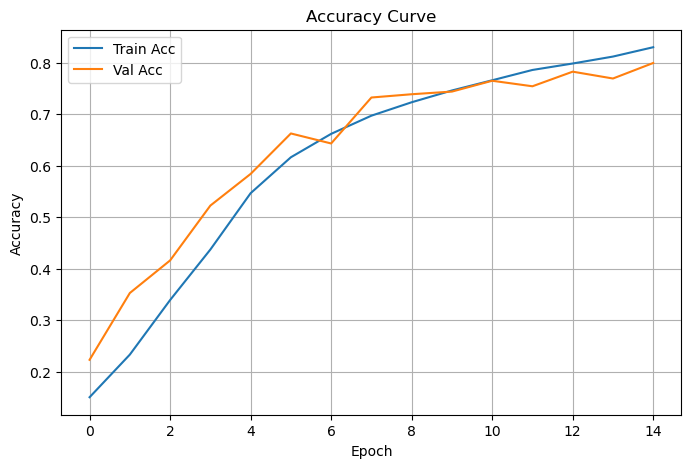

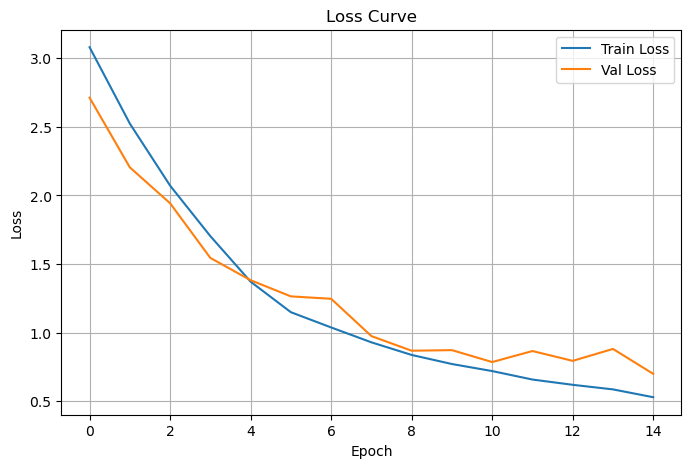

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val_pad)
y_pred_cls = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_val_enc, y_pred_cls)
print("Final Validation Accuracy:", acc)

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
Final Validation Accuracy: 0.7992859976199921


In [12]:
sample = X_val_pad[0:1]
pred = model.predict(sample)[0]

top3 = pred.argsort()[-3:][::-1]

print("Top 3 predicted writer IDs:", top3)
print("Probabilities:", pred[top3])
print("True writer ID:", y_val_enc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Top 3 predicted writer IDs: [15  0 12]
Probabilities: [0.6073452  0.23899828 0.12836951]
True writer ID: 0


In [13]:
import random

for i in random.sample(range(len(X_val_pad)), 5):
    p = np.argmax(model.predict(X_val_pad[i:i+1]))
    print(f"Sample {i}: Pred = {p}, True = {y_val_enc[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Sample 5027: Pred = 52, True = 52
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Sample 2061: Pred = 21, True = 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Sample 2809: Pred = 28, True = 28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Sample 3989: Pred = 39, True = 39
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Sample 866: Pred = 8, True = 8


158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


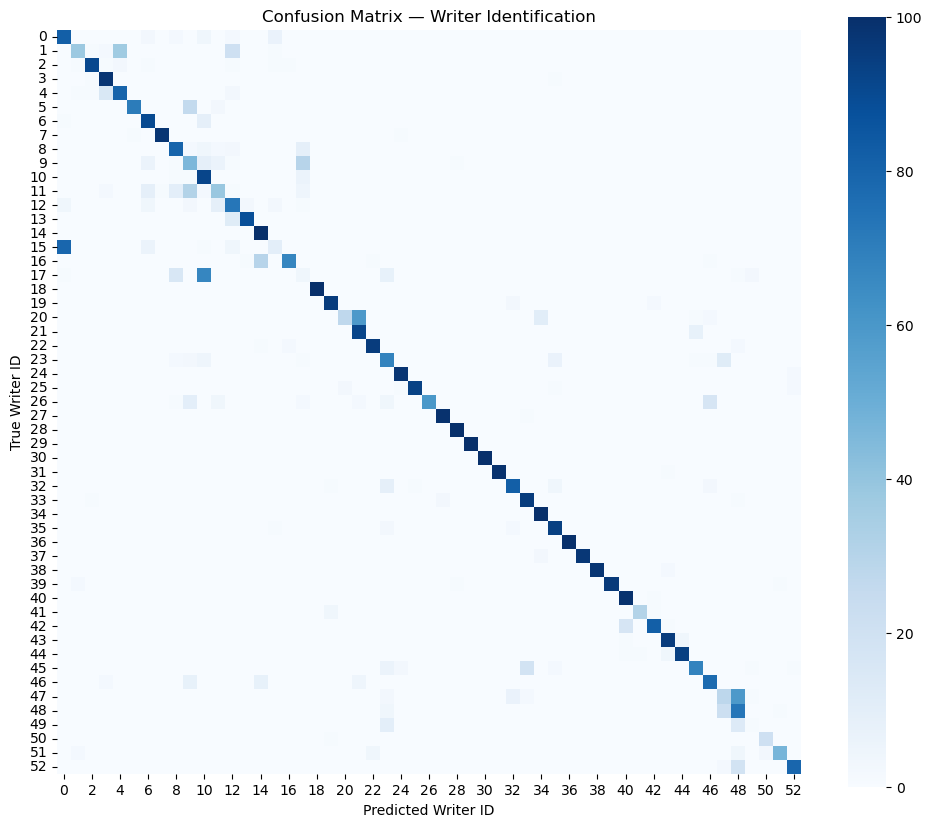

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val_pad)
y_pred_cls = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val_enc, y_pred_cls)
cm.shape

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", square=True, cbar=True)
plt.title("Confusion Matrix — Writer Identification")
plt.xlabel("Predicted Writer ID")
plt.ylabel("True Writer ID")
plt.show()